## Determining the phase shifts for scattering in a Lennard-Jones potential

In this notebook we'll study the scattering states in a Lennard-Jones potential:

$$
V(r) = 4\epsilon \left[ \left(\frac{\sigma}{r}\right)^{12} - \left(\frac{\sigma}{r}\right)^6\right]
$$ù

In [ ]:
import numpy as np
import physipy as phys
import matplotlib.pyplot as plt
import scipy.constants as const

In [2]:
m_H  = 1.008 * const.u          # kg
m_Kr = 83.798 * const.u         # kg
mu   = m_H * m_Kr / (m_H + m_Kr)  # kg

hbar2_over_2mu = const.hbar**2 / (2 * mu)  # J·m²
hbar2_over_2mu_meV_A2 = hbar2_over_2mu * 6.242e21 * 1e20
print(f"ℏ²/2µ = {hbar2_over_2mu_meV_A2:.6f} meV·Å²")

ℏ²/2µ = 2.098599 meV·Å²


We start by setting arbitrarly the parameters $$\epsilon = 5.99 \text{ meV}$$ and $$\sigma = 2.00 Å$$

In [49]:
kwargs = {'hbar_squared_over_2_m' : 2.098599, 'sigma' : 2, 'epsilon' : 5.99}
cmap = plt.get_cmap('tab20')

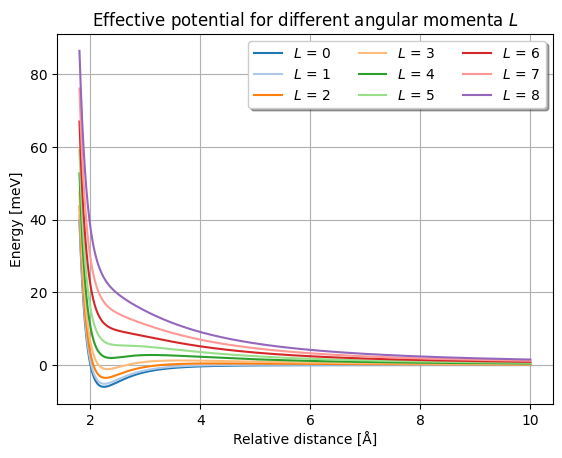

In [51]:
# print the effective potential for different angular momenta
r = np.linspace(0.9 * kwargs['sigma'], 10, 1000)
ls = np.arange(0, 9, 1)

plt.title('Effective potential for different angular momenta $L$')
i = 0
for _l in ls:
    color = cmap(i)
    plt.plot(r, phys.effective_potential(r, _l, phys.lennard_jones, **kwargs), color = color, label = f'$L$ = {_l}')
    i += 1

plt.xlabel('Relative distance [Å]')
plt.ylabel('Energy [meV]')
plt.legend(ncols = 3, fancybox = True, shadow = True)
plt.grid()
plt.show()


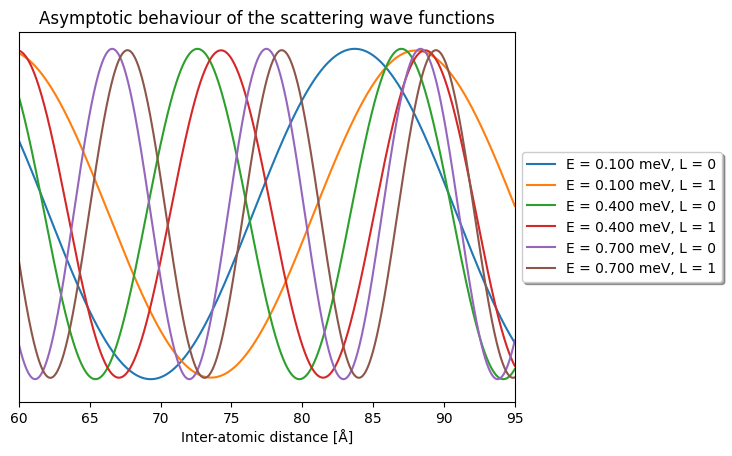

In [52]:
# print a few oscillations in the asymptotic regime
h = 1e-3
r_max = 100
E = np.arange(0.1, 1, .3)
ls = np.arange(0, 2, 1)

grid = phys.potentials.helper_grid_lj(h, r_max, sigma = kwargs['sigma'])
solver = phys.numerics.SolverOpts()

plt.title('Asymptotic behaviour of the scattering wave functions')
i = 0
for _E in E:
    for _l in ls:
        coord, psi = phys.scattering.integrate_scattering_state(_E, _l, phys.potentials.lennard_jones, grid = grid, solver = solver, **kwargs)
        color = cmap(i)
        plt.plot(coord, psi/np.max(psi), label = f'E = {_E:.3f} meV, L = {_l}')
        i += 1

plt.legend(loc = 'center left', ncols = 1, bbox_to_anchor=(1, 0.5), fancybox = True, shadow = True)
plt.yticks(ticks = [])
plt.xlim([60, 95])
plt.xlabel('Inter-atomic distance [Å]')
plt.show()


Solve the Schrodinger equation for $l \in [0, 6]$ and $E \in [0.1, 3.5)$

In [58]:
ls = np.arange(0, 7, 1)
E = np.linspace(0.01, 3.5, 200)
hs = [1e-1, 1e-2, 1e-3]
solver = phys.numerics.SolverOpts()

In [33]:
i = 0
phases = np.zeros((len(hs), len(E), len(ls)))

for _h in hs:
    j = 0
    for _E in E:
        z = 0
        for _l in ls:
            points_needed = phys.n_points_needed(_E, kwargs['hbar_squared_over_2_m'], _h)
            r_min = phys.r_asym_min(_E, _l, phys.lennard_jones, kwargs['hbar_squared_over_2_m'], **kwargs)
            r_max = r_min + points_needed * _h
            grid = phys.potentials.helper_grid_lj(_h, r_max, sigma = kwargs['sigma'])
            print(f'For E = {_E:.3f} and l = {_l} h = {_h:.2e} r_min = {r_min:.3f} r_max = {r_max:.3f} and points_needed = {points_needed}')
            coord, psi = phys.integrate_scattering_state(_E, _l, phys.lennard_jones, grid = grid, solver = solver, store_wavefunction = False, n_points = points_needed, **kwargs)
            # compute phases
            mean_phase, std_phase = phys.compute_phase_shift(psi, coord, _E, _l, **kwargs)
            print(f'For E = {_E:.3f} and l = {_l} h = {_h:.2e} ps = {mean_phase:.2e} with std dev = {std_phase:.2e}')
            phases[i, j, z] = mean_phase
            z += 1
        j += 1
    i += 1
    

For E = 0.010 and l = 0 h = 1.00e-01 r_min = 31.600 r_max = 304.700 and points_needed = 2731
For E=0.010 and l=0 r1=72.90, r2=95.60 → δ = -0.323463 rad
For E=0.010 and l=0 r1=163.90, r2=186.60 → δ = -0.322078 rad
For E=0.010 and l=0 r1=255.00, r2=277.70 → δ = -0.320432 rad
For E = 0.010 and l = 0 h = 1.00e-01 ps = -3.22e-01 with std dev = 1.24e-03
For E = 0.010 and l = 1 h = 1.00e-01 r_min = 40.974 r_max = 314.074 and points_needed = 2731
For E=0.010 and l=1 r1=89.10, r2=112.00 → δ = -0.053581 rad
For E=0.010 and l=1 r1=272.80, r2=295.70 → δ = -0.035305 rad
For E = 0.010 and l = 1 h = 1.00e-01 ps = -4.44e-02 with std dev = 9.14e-03
For E = 0.010 and l = 2 h = 1.00e-01 r_min = 70.969 r_max = 344.069 and points_needed = 2731
For E=0.010 and l=2 r1=155.20, r2=178.20 → δ = 3.134994 rad
For E=0.010 and l=2 r1=247.80, r2=270.80 → δ = -3.140584 rad
For E = 0.010 and l = 2 h = 1.00e-01 ps = -2.80e-03 with std dev = 3.80e-03
For E = 0.010 and l = 3 h = 1.00e-01 r_min = 100.366 r_max = 373.466 a

In [54]:
phases_unwrap = np.unwrap(phases, period=np.pi, axis = 1)

In [57]:
phases_unwrap.shape

(3, 200, 7)

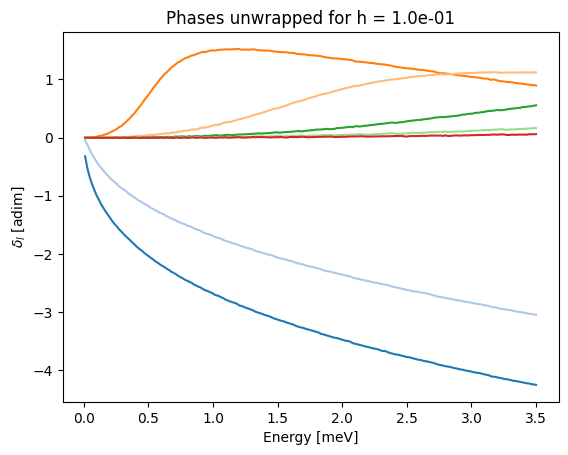

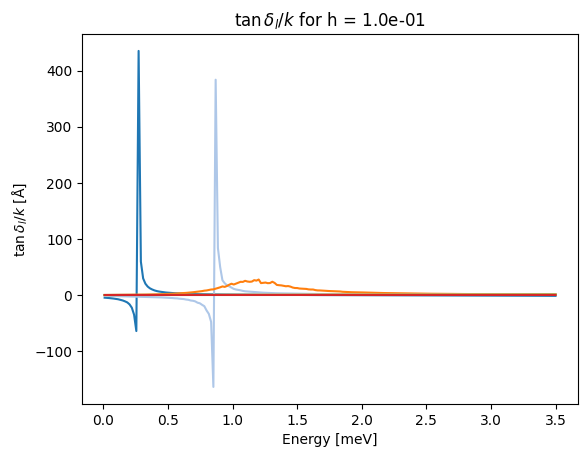

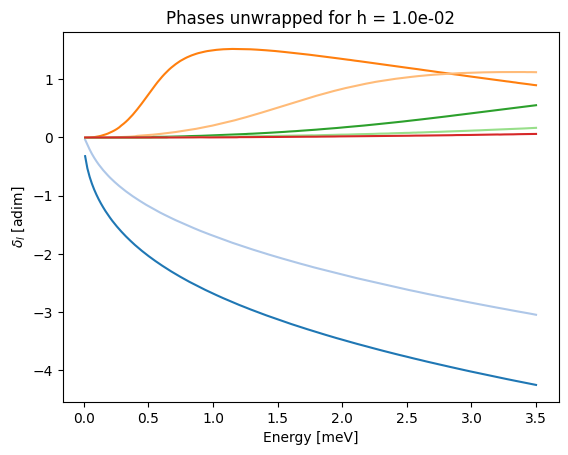

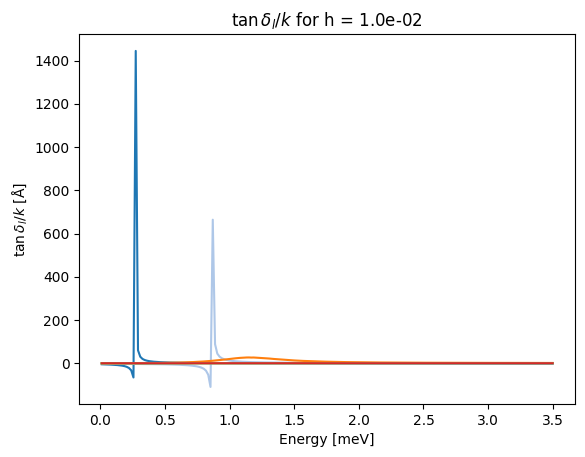

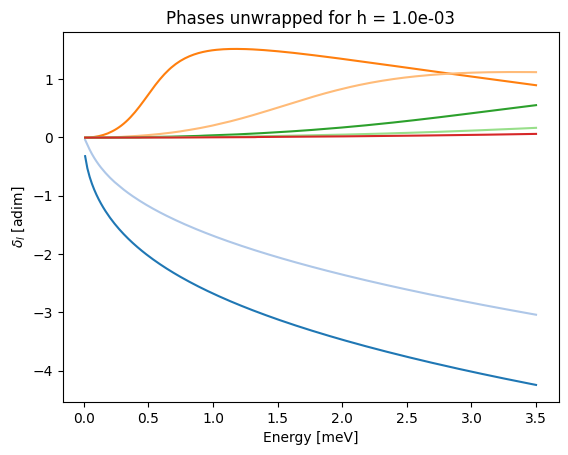

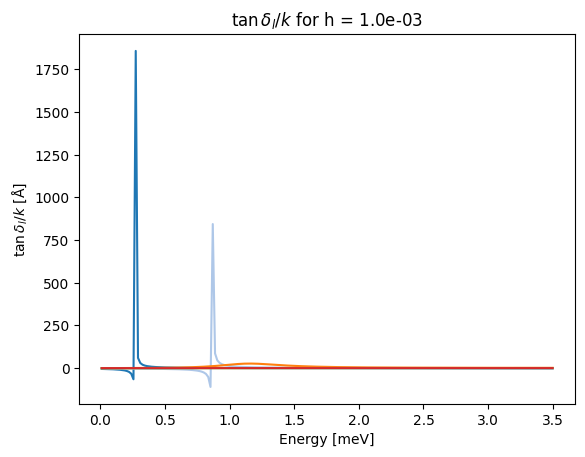

In [64]:
k = 0
colors = [cmap(i) for i in range(cmap.N)]
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=colors)

for h in hs:
    plt.title(f'Phases unwrapped for h = {h:.1e}')
    plt.xlabel('Energy [meV]')
    plt.ylabel(r'$\delta_l$ [adim]')
    plt.plot(E, phases_unwrap[k, :, :])
    plt.show()
    plt.xlabel('Energy [meV]')
    plt.ylabel(r'$\tan{\delta_l} / k$ [Å]')
    plt.title(r'$\tan{\delta_l} / k$' + f' for h = {h:.1e}')
    plt.plot(E, (np.tan(phases_unwrap[k, :, :]) / phys.wave_vector(E[:, None], **kwargs)))
    plt.show()
    k += 1

In [37]:
cross_sections = np.zeros((len(hs), len(E)))
i = 0

for h in hs:
    j = 0
    for _l in ls:
        cross_sections[i] += 4 * np.pi * kwargs['hbar_squared_over_2_m'] * (2 * _l + 1) * np.pow(np.sin(phases_unwrap[i, :, j]), 2) / E
        j += 1
    i += 1

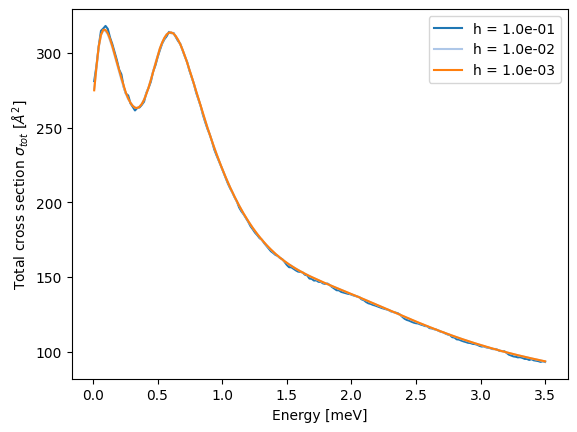

In [65]:
i = 0

for h in hs:
    plt.ylabel(r'Total cross section $\sigma_{tot}$ [$Å^2$]')
    plt.xlabel('Energy [meV]')
    plt.plot(E, cross_sections[i], label = f'h = {h:.1e}')
    i += 1

plt.legend()
plt.show()

For h = 1.0e-01 found peak at 0.098.
For h = 1.0e-01 found peak at 0.589.
For h = 1.0e-01 found peak at 0.624.
For h = 1.0e-01 found peak at 1.729.
For h = 1.0e-01 found peak at 1.816.
For h = 1.0e-01 found peak at 3.026.
For h = 1.0e-01 found peak at 3.114.
For h = 1.0e-01 found peak at 3.307.
For h = 1.0e-01 found peak at 3.395.
For h = 1.0e-01 found peak at 3.482.


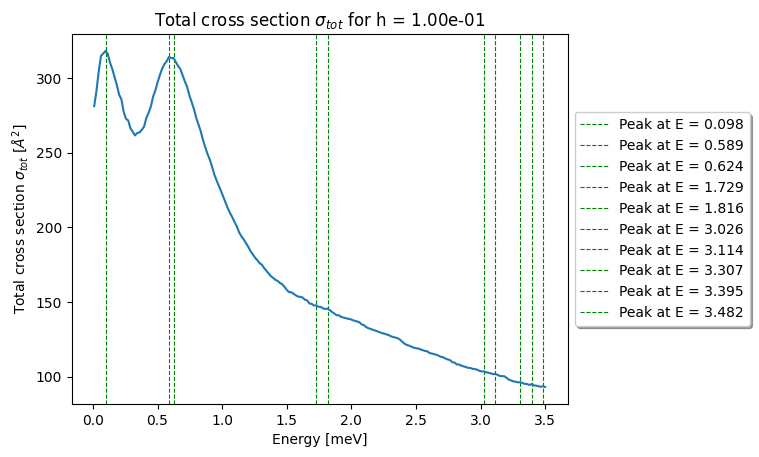

For h = 1.0e-02 found peak at 0.080.
For h = 1.0e-02 found peak at 0.606.


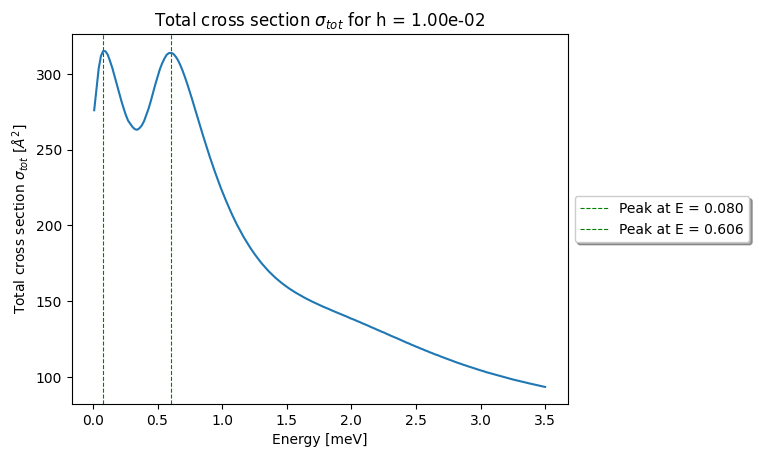

For h = 1.0e-03 found peak at 0.080.
For h = 1.0e-03 found peak at 0.606.


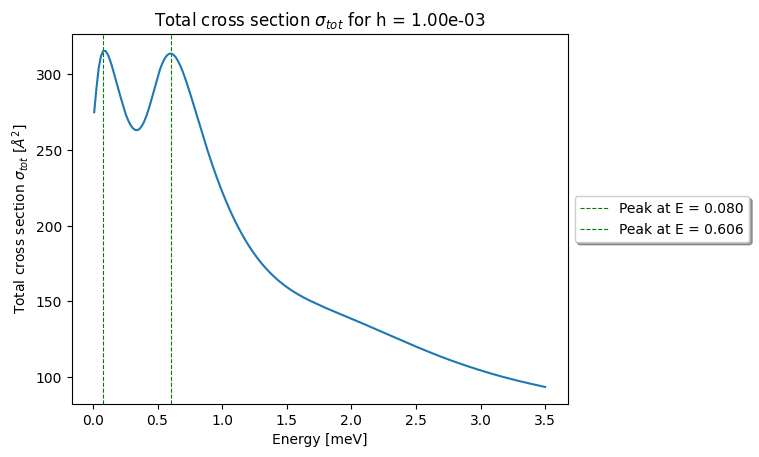

In [76]:
from scipy.signal import find_peaks
i = 0

for h in hs:
    peaks, _ = find_peaks(cross_sections[i])
    for peak in peaks:
        print(f'For h = {h:.1e} found peak at {E[peak]:.3f}.')
        plt.axvline(E[peak], ymin=0, ymax=1, color='g', linestyle = 'dashed', linewidth=0.8, label = f'Peak at E = {E[peak]:.3f}')
    plt.title(r'Total cross section $\sigma_{tot}$ for ' + f'h = {h:.2e}')
    plt.ylabel(r'Total cross section $\sigma_{tot}$ [$Å^2$]')
    plt.xlabel('Energy [meV]')
    plt.plot(E, cross_sections[i])
    plt.legend(loc = 'center left', ncols = 1, bbox_to_anchor=(1, 0.5), fancybox = True, shadow = True)
    plt.show()
    i += 1

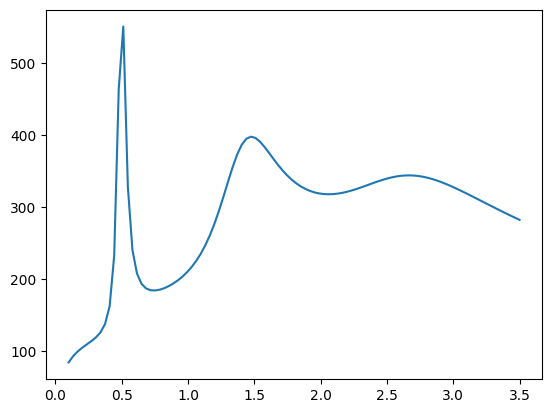

In [ ]:
plt.plot(E, cross_section)